In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms # New imports for FashionMNIST
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# --- Configuration ---
# FashionMNIST images are 28x28 grayscale
IMAGE_HEIGHT = 28
IMAGE_WIDTH = 28
NUM_CLASSES = 10 # FashionMNIST has 10 classes
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 20 # Reduced for quicker demo, feel free to increase (e.g., 50)

# --- Hour 1: Dataset Preparation and Introduction to CNNs ---

print("--- Hour 1: Dataset Preparation and Introduction to CNNs ---")

# Step 1: Introduction to CNNs (Conceptual - No code required here, discussed in lab)
print("\nStep 1: Introduction to CNNs (Conceptual - discussion during lab)")

# Step 2: Dataset Setup

print("\nStep 2: Dataset Setup - Loading and Normalizing Data (FashionMNIST)...")

# Define transformations
# ToTensor() converts PILImage or numpy.ndarray to FloatTensor and scales pixels to [0, 1]
# Normalize() then scales to [-1, 1] for better training performance
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Mean and std for single channel
])

# Load FashionMNIST datasets
# train=True downloads the training part (60,000 images)
# train=False downloads the test part (10,000 images)
# download=True will download if not already present
train_val_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

print(f"FashionMNIST loaded. Total training/validation samples: {len(train_val_dataset)}")
print(f"Total test samples: {len(test_dataset)}")
print(f"Sample image shape: {train_val_dataset[0][0].shape} (Channels, Height, Width)")
print(f"Sample label: {train_val_dataset[0][1]}")

# Split the training/validation dataset into training and validation sets
train_size = int(0.8 * len(train_val_dataset)) # 80% for training
val_size = len(train_val_dataset) - train_size # 20% for validation
train_dataset, val_dataset = random_split(train_val_dataset, [train_size, val_size])

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False) # Use separate test_dataset

print("DataLoaders created.")


--- Hour 1: Dataset Preparation and Introduction to CNNs ---

Step 1: Introduction to CNNs (Conceptual - discussion during lab)

Step 2: Dataset Setup - Loading and Normalizing Data (FashionMNIST)...
FashionMNIST loaded. Total training/validation samples: 60000
Total test samples: 10000
Sample image shape: torch.Size([1, 28, 28]) (Channels, Height, Width)
Sample label: 9
Training samples: 48000
Validation samples: 12000
DataLoaders created.


In [9]:

# --- Hour 2: CNN Model Building and Training ---

print("\n--- Hour 2: CNN Model Building and Training ---")

# Step 3: Define the Baseline CNN Model

class SimpleCNN(nn.Module):
    def __init__(self, num_classes, img_height, img_width):
        super(SimpleCNN, self).__init__()
        # Input channel is 1 for grayscale image
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Calculate the size of the features after convolutional and pooling layers
        # Use a dummy tensor to calculate the flattened size dynamically
        # This makes the model more robust to different input image sizes
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, img_height, img_width) # (Batch, Channels, H, W)
            x = self.pool1(self.relu1(self.conv1(dummy_input)))
            x = self.pool2(self.relu2(self.conv2(x)))
            self._to_linear = x.view(x.size(0), -1).size(1) # Flatten and get size

        # Ensure the calculated dimension is positive
        if self._to_linear <= 0:
            raise ValueError(f"Calculated FC input dimension is {self._to_linear}. This usually means pooling reduced dimensions to zero. Check IMAGE_HEIGHT, IMAGE_WIDTH, and pooling parameters. For 28x28, it should work fine.")


        self.fc = nn.Linear(self._to_linear, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.view(x.size(0), -1) # Flatten for the fully connected layer
        x = self.fc(x)
        return x

print("\nStep 3: Define the Baseline CNN Model - Initializing model...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = SimpleCNN(NUM_CLASSES, IMAGE_HEIGHT, IMAGE_WIDTH).to(device)
print(model)

# Step 4: Train the CNN Model

print("\nStep 4: Train the CNN Model - Starting training...")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_accuracy = 100 * correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_accuracy = 100 * correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], '
          f'Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.2f}%, '
          f'Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.2f}%')

print("Training finished.")



--- Hour 2: CNN Model Building and Training ---

Step 3: Define the Baseline CNN Model - Initializing model...
Using device: cpu
SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)

Step 4: Train the CNN Model - Starting training...
Epoch [1/20], Train Loss: 0.5102, Train Acc: 81.89%, Val Loss: 0.3507, Val Acc: 87.55%
Epoch [2/20], Train Loss: 0.3401, Train Acc: 88.02%, Val Loss: 0.3312, Val Acc: 88.16%
Epoch [3/20], Train Loss: 0.2996, Train Acc: 89.31%, Val Loss: 0.2970, Val Acc: 89.78%
Epoch [4/20], Train Loss: 0.2717, Train Acc: 90.34%, Val Loss: 0.2831, Val Acc: 89.73%
Epoch [5/20], Train Loss: 0.2509, T


--- Hour 3: Evaluation, Visualization, and Analysis ---

Step 5: Evaluate the Model - Computing test accuracy...
Final Test Accuracy of the model on the 10000 test images: 90.86%

Generating Confusion Matrix...


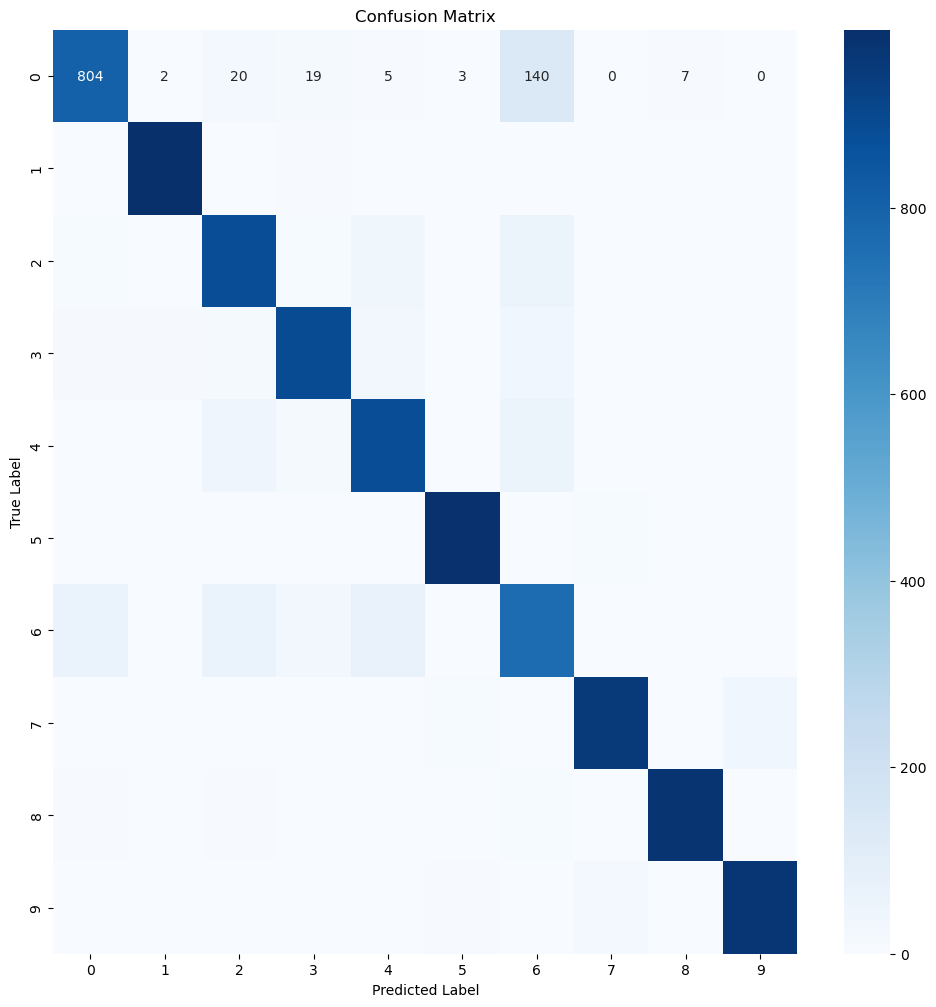

Confusion Matrix generated.


In [10]:

# --- Hour 3: Evaluation, Visualization, and Analysis ---

print("\n--- Hour 3: Evaluation, Visualization, and Analysis ---")

# Step 5: Evaluate the Model


print("\nStep 5: Evaluate the Model - Computing test accuracy...")
model.eval()
correct_test = 0
total_test = 0
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels in test_loader: # Using the dedicated test_loader
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct_test / total_test
print(f'Final Test Accuracy of the model on the {total_test} test images: {test_accuracy:.2f}%')

# Optional: Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(all_true_labels, all_predictions)
plt.figure(figsize=(NUM_CLASSES + 2, NUM_CLASSES + 2)) # Adjust figure size dynamically
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(range(NUM_CLASSES)), # Can use actual class names if available
            yticklabels=list(range(NUM_CLASSES)))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
print("Confusion Matrix generated.")




Step 6: Visualize Results - Plotting accuracy and loss curves...


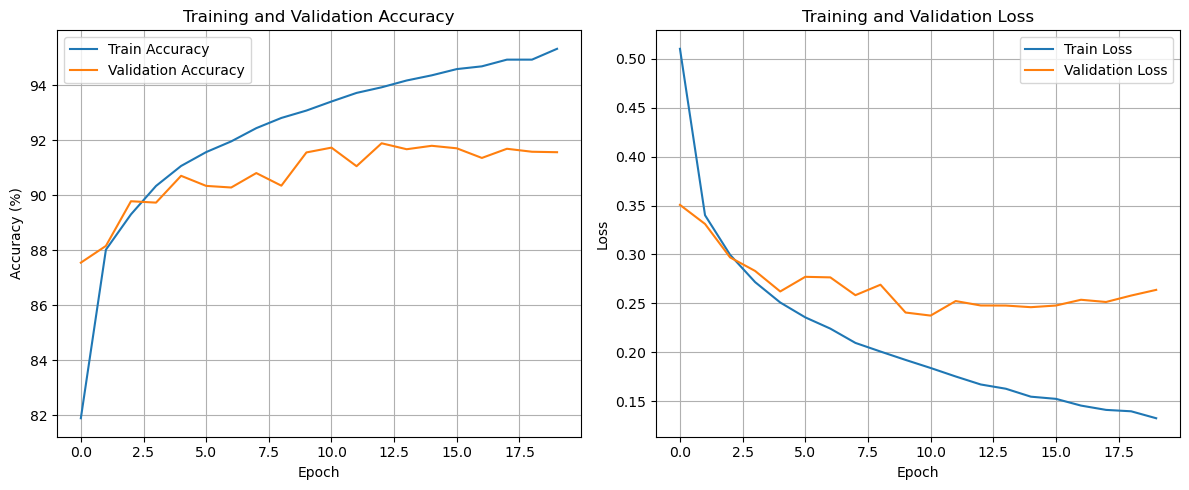

Accuracy and Loss curves plotted.


In [11]:

# Step 6: Visualize Results

print("\nStep 6: Visualize Results - Plotting accuracy and loss curves...")

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
print("Accuracy and Loss curves plotted.")
